In [1]:
import polars as pl

catalina_path = "/home/rohan/agn_photometry/photometry/results/catalina_photometry.parquet"
alerce_path   = "/home/rohan/agn_photometry/photometry/results/alerce_photometry.parquet"
atlas_path    = "/home/rohan/agn_photometry/photometry/results/atlas_photometry.parquet"

# outputs for this new analysis live under structure_function_fractional_variability/results
sf_fvar_results_dir = "/home/rohan/agn_photometry/structure_function_fractional_variability/results"

df_catalina = pl.read_parquet(catalina_path)
df_alerce   = pl.read_parquet(alerce_path)
df_atlas    = pl.read_parquet(atlas_path)

def cadence_summary(df, time_col, group_cols, survey_name):
    return (
        df.group_by(group_cols)
        .agg([
            pl.len().alias("N"),
            (pl.col(time_col).max() - pl.col(time_col).min()).alias("baseline_days"),
        ])
        .with_columns(pl.lit(survey_name).alias("survey"))
        .sort("N", descending=True)
    )

catalina_cadence = cadence_summary(
    df_catalina, "MJD", ["source_name"], "Catalina"
).with_columns(pl.lit(None, dtype=pl.Utf8).alias("band"))

alerce_cadence = cadence_summary(
    df_alerce, "mjd", ["source_name", "fid"], "ALERCE"
).rename({"fid": "band"}).with_columns(pl.col("band").cast(pl.Utf8))

atlas_cadence = cadence_summary(
    df_atlas, "MJD", ["source_name", "F"], "ATLAS"
).rename({"F": "band"}).with_columns(pl.col("band").cast(pl.Utf8))

cadence_all = pl.concat(
    [catalina_cadence, alerce_cadence, atlas_cadence],
    how="diagonal",
).select(["survey", "source_name", "band", "N", "baseline_days"])

# Tiering: N >= 50 and baseline >= 365d -> trusted; N >= 20 -> marginal; else -> excluded
cadence_all = cadence_all.with_columns(
    pl.when((pl.col("N") >= 50) & (pl.col("baseline_days") >= 365))
      .then(pl.lit("trusted"))
      .when(pl.col("N") >= 20)
      .then(pl.lit("marginal"))
      .otherwise(pl.lit("excluded"))
      .alias("tier")
)

pl.Config.set_tbl_rows(-1)
print(cadence_all)

print("\nTier counts by survey:")
print(cadence_all.group_by(["survey", "tier"]).agg(pl.len().alias("count")).sort(["survey", "tier"]))

output_path = f"{sf_fvar_results_dir}/cadence_summary.parquet"
cadence_all.write_parquet(output_path)
print(f"\nSaved to {output_path}")

shape: (127, 6)
┌──────────┬────────────────────┬──────┬──────┬───────────────┬──────────┐
│ survey   ┆ source_name        ┆ band ┆ N    ┆ baseline_days ┆ tier     │
│ ---      ┆ ---                ┆ ---  ┆ ---  ┆ ---           ┆ ---      │
│ str      ┆ str                ┆ str  ┆ u64  ┆ f64           ┆ str      │
╞══════════╪════════════════════╪══════╪══════╪═══════════════╪══════════╡
│ Catalina ┆ 110104.14+062829.5 ┆ null ┆ 897  ┆ 3166.16978    ┆ trusted  │
│ Catalina ┆ 161742.53+322234.4 ┆ null ┆ 727  ┆ 3078.76041    ┆ trusted  │
│ Catalina ┆ 095919.14+090659.4 ┆ null ┆ 689  ┆ 3180.26115    ┆ trusted  │
│ Catalina ┆ 150348.33+193941.3 ┆ null ┆ 670  ┆ 3032.83473    ┆ trusted  │
│ Catalina ┆ 093856.54+435415.0 ┆ null ┆ 669  ┆ 2902.07766    ┆ trusted  │
│ Catalina ┆ 121028.83+025454.2 ┆ null ┆ 504  ┆ 2999.88549    ┆ trusted  │
│ Catalina ┆ 022325.01-003612.6 ┆ null ┆ 493  ┆ 2963.95944    ┆ trusted  │
│ Catalina ┆ 075005.28+292944.3 ┆ null ┆ 473  ┆ 3090.31711    ┆ trusted  │
│ Catalin

In [2]:
import polars as pl
import numpy as np

catalina_path  = "/home/rohan/agn_photometry/photometry/results/catalina_photometry.parquet"
alerce_path    = "/home/rohan/agn_photometry/photometry/results/alerce_photometry.parquet"
atlas_path     = "/home/rohan/agn_photometry/photometry/results/atlas_photometry.parquet"
cadence_path   = "/home/rohan/agn_photometry/structure_function_fractional_variability/results/cadence_summary.parquet"

df_catalina = pl.read_parquet(catalina_path)
df_alerce   = pl.read_parquet(alerce_path)
df_atlas    = pl.read_parquet(atlas_path)
cadence     = pl.read_parquet(cadence_path)

def remove_outliers_mask(mag_vals, threshold=4.0):
    """Same MAD-based logic as Photometry.ipynb's remove_outliers, returns a boolean mask."""
    y_arr = mag_vals.to_numpy()
    n = len(y_arr)
    if n < 3:
        return np.ones(n, dtype=bool)
    median = np.median(y_arr)
    mad = np.median(np.abs(y_arr - median))
    if mad == 0:
        return np.ones(n, dtype=bool)
    modified_z = 0.6745 * (y_arr - median) / mad
    return np.abs(modified_z) < threshold

def apply_mad_filter(df, mag_col, group_cols, err_col=None):
    """Apply MAD outlier removal independently within each (source, band) group.
    If err_col is given, points that are outliers in EITHER mag or error are dropped."""
    kept_frames = []
    for _, sub in df.group_by(group_cols):
        mask = remove_outliers_mask(sub[mag_col])
        if err_col is not None:
            err_mask = remove_outliers_mask(sub[err_col])
            mask = mask & err_mask
        kept_frames.append(sub.filter(pl.Series(mask)))
    return pl.concat(kept_frames)

df_catalina = apply_mad_filter(df_catalina, "mag", ["source_name"], err_col="mag_err")
df_alerce   = apply_mad_filter(df_alerce, "magpsf_corr", ["source_name", "fid"], err_col="sigmapsf")
df_atlas    = apply_mad_filter(df_atlas, "m", ["source_name", "F"], err_col="dm")
df_atlas = df_atlas.rename({"F": "band"})

# ---- mag -> flux, per row ----
def add_flux_cols(df, mag_col, magerr_col):
    return df.with_columns([
        (10 ** (-0.4 * pl.col(mag_col))).alias("F"),
    ]).with_columns([
        (0.4 * np.log(10) * pl.col("F") * pl.col(magerr_col)).alias("sigma_F"),
    ])

df_catalina = add_flux_cols(df_catalina, "mag", "mag_err").with_columns(
    pl.lit(None, dtype=pl.Utf8).alias("band")
)
df_alerce = add_flux_cols(df_alerce, "magpsf_corr", "sigmapsf").with_columns(
    pl.col("fid").cast(pl.Utf8).alias("band")
)
df_atlas = add_flux_cols(df_atlas, "m", "dm").with_columns(
    pl.col("band").cast(pl.Utf8)
)

df_catalina = df_catalina.with_columns(pl.lit("Catalina").alias("survey"))
df_alerce   = df_alerce.with_columns(pl.lit("ALERCE").alias("survey"))
df_atlas    = df_atlas.with_columns(pl.lit("ATLAS").alias("survey"))

# ---- Fvar per (survey, source_name, band) ----
def fvar_per_group(df):
    return (
        df.group_by(["survey", "source_name", "band"])
        .agg([
            pl.len().alias("N"),
            pl.col("F").mean().alias("F_mean"),
            pl.col("F").var(ddof=1).alias("S2"),
            (pl.col("sigma_F") ** 2).mean().alias("sigma2_err_mean"),
        ])
        .with_columns(
            ((pl.col("S2") - pl.col("sigma2_err_mean")) / (pl.col("F_mean") ** 2))
            .alias("excess_var_norm")
        )
        .with_columns(
            pl.when(pl.col("excess_var_norm") > 0)
              .then(pl.col("excess_var_norm").sqrt())
              .otherwise(None)
              .alias("Fvar")
        )
    )

fvar_catalina = fvar_per_group(df_catalina)
fvar_alerce   = fvar_per_group(df_alerce)
fvar_atlas    = fvar_per_group(df_atlas)

fvar_all = pl.concat([fvar_catalina, fvar_alerce, fvar_atlas], how="diagonal")

# ---- join cadence tiers, drop excluded ----
fvar_all = fvar_all.join(
    cadence.select(["survey", "source_name", "band", "baseline_days", "tier"]),
    on=["survey", "source_name", "band"],
    how="left",
    nulls_equal=True,
)

fvar_trusted = fvar_all.filter(pl.col("tier") != "excluded")

pl.Config.set_tbl_rows(-1)
print(fvar_trusted.select([
    "survey", "source_name", "band", "N", "baseline_days", "tier", "Fvar"
]).sort(["survey", "source_name"]))

output_path = "/home/rohan/agn_photometry/structure_function_fractional_variability/results/fvar_all_surveys.parquet"
fvar_trusted.write_parquet(output_path)
print(f"\nSaved to {output_path}")

shape: (108, 7)
┌──────────┬────────────────────┬──────┬──────┬───────────────┬──────────┬──────────┐
│ survey   ┆ source_name        ┆ band ┆ N    ┆ baseline_days ┆ tier     ┆ Fvar     │
│ ---      ┆ ---                ┆ ---  ┆ ---  ┆ ---           ┆ ---      ┆ ---      │
│ str      ┆ str                ┆ str  ┆ u64  ┆ f64           ┆ str      ┆ f64      │
╞══════════╪════════════════════╪══════╪══════╪═══════════════╪══════════╪══════════╡
│ ALERCE   ┆ 001255.59+014750.9 ┆ 1    ┆ 195  ┆ 2305.698507   ┆ trusted  ┆ 0.224405 │
│ ALERCE   ┆ 001255.59+014750.9 ┆ 2    ┆ 103  ┆ 2297.776586   ┆ trusted  ┆ 0.09675  │
│ ALERCE   ┆ 022325.01-003612.6 ┆ 1    ┆ 136  ┆ 1537.936331   ┆ trusted  ┆ null     │
│ ALERCE   ┆ 075947.73+112507.3 ┆ 2    ┆ 112  ┆ 1086.917338   ┆ trusted  ┆ null     │
│ ALERCE   ┆ 075947.73+112507.3 ┆ 1    ┆ 83   ┆ 1108.989977   ┆ trusted  ┆ 0.130613 │
│ ALERCE   ┆ 082311.26+435318.5 ┆ 2    ┆ 24   ┆ 370.015567    ┆ marginal ┆ null     │
│ ALERCE   ┆ 095746.83+303024.2 ┆ 2   

In [3]:
import polars as pl
import numpy as np

catalina_path = "/home/rohan/agn_photometry/photometry/results/catalina_photometry.parquet"
alerce_path   = "/home/rohan/agn_photometry/photometry/results/alerce_photometry.parquet"

df_catalina = pl.read_parquet(catalina_path)
df_alerce   = pl.read_parquet(alerce_path)

print("=" * 70)
print("CATALINA: 205601.38-062049.7 (Fvar = 3.46 outlier)")
print("=" * 70)
sub = df_catalina.filter(pl.col("source_name") == "205601.38-062049.7")
print(f"N = {sub.height}")
print(sub.select(["MJD", "mag", "mag_err"]).describe())
print("\nSorted by mag (brightest and faintest 5 points):")
print(sub.sort("mag").select(["MJD", "mag", "mag_err"]).head(5))
print(sub.sort("mag").select(["MJD", "mag", "mag_err"]).tail(5))

print("\n" + "=" * 70)
print("ALERCE: 132404.20+433407.1 (null Fvar in BOTH bands despite N=225/139)")
print("=" * 70)
sub2 = df_alerce.filter(pl.col("source_name") == "132404.20+433407.1")
print(f"Total N (both bands) = {sub2.height}")
for band in sub2["fid"].unique().sort():
    b = sub2.filter(pl.col("fid") == band)
    print(f"\n--- fid={band}, N={b.height} ---")
    print(b.select(["magpsf_corr", "sigmapsf"]).describe())

CATALINA: 205601.38-062049.7 (Fvar = 3.46 outlier)
N = 326
shape: (9, 4)
┌────────────┬──────────────┬───────────┬──────────┐
│ statistic  ┆ MJD          ┆ mag       ┆ mag_err  │
│ ---        ┆ ---          ┆ ---       ┆ ---      │
│ str        ┆ f64          ┆ f64       ┆ f64      │
╞════════════╪══════════════╪═══════════╪══════════╡
│ count      ┆ 326.0        ┆ 326.0     ┆ 326.0    │
│ null_count ┆ 0.0          ┆ 0.0       ┆ 0.0      │
│ mean       ┆ 55054.772015 ┆ 19.155706 ┆ 0.199908 │
│ std        ┆ 951.914692   ┆ 0.445421  ┆ 0.045088 │
│ min        ┆ 53525.3978   ┆ 14.37     ┆ 0.13     │
│ 25%        ┆ 54233.44104  ┆ 18.95     ┆ 0.17     │
│ 50%        ┆ 55058.26778  ┆ 19.12     ┆ 0.19     │
│ 75%        ┆ 55850.15842  ┆ 19.37     ┆ 0.22     │
│ max        ┆ 56593.12599  ┆ 20.38     ┆ 0.5      │
└────────────┴──────────────┴───────────┴──────────┘

Sorted by mag (brightest and faintest 5 points):
shape: (5, 3)
┌─────────────┬───────┬─────────┐
│ MJD         ┆ mag   ┆ mag_err │


In [4]:
import polars as pl
import numpy as np

atlas_path = "/home/rohan/agn_photometry/photometry/results/atlas_photometry.parquet"
df_atlas = pl.read_parquet(atlas_path)

# Same MAD filter as the main pipeline, applied here for a fair comparison
def remove_outliers_mask(mag_vals, threshold=4.0):
    y_arr = mag_vals.to_numpy()
    n = len(y_arr)
    if n < 3:
        return np.ones(n, dtype=bool)
    median = np.median(y_arr)
    mad = np.median(np.abs(y_arr - median))
    if mad == 0:
        return np.ones(n, dtype=bool)
    modified_z = 0.6745 * (y_arr - median) / mad
    return np.abs(modified_z) < threshold

sources_to_check = ["001255.59+014750.9", "113618.90+125554.8", "150348.33+193941.3"]

for src in sources_to_check:
    print("=" * 70)
    print(f"{src}")
    print("=" * 70)
    for band in ["c", "o"]:
        sub = df_atlas.filter(
            (pl.col("source_name") == src) & (pl.col("F") == band)
        )
        mag_mask = remove_outliers_mask(sub["m"])
        err_mask = remove_outliers_mask(sub["dm"])
        mask = mag_mask & err_mask
        sub_clean = sub.filter(pl.Series(mask))

        m = sub_clean["m"].to_numpy()
        dm = sub_clean["dm"].to_numpy()
        flux = 10 ** (-0.4 * m)
        sigma_flux = 0.4 * np.log(10) * flux * dm

        S2 = np.var(flux, ddof=1)
        sigma2_err_mean = np.mean(sigma_flux ** 2)
        excess = S2 - sigma2_err_mean

        print(f"\n--- band={band}, N={len(m)} (after MAD filter) ---")
        print(f"  mag std      = {np.std(m):.5f}")
        print(f"  mean dm      = {np.mean(dm):.5f}")
        print(f"  median dm    = {np.median(dm):.5f}")
        print(f"  max dm       = {np.max(dm):.5f}")
        print(f"  flux S2      = {S2:.6e}")
        print(f"  mean sigma_F^2 = {sigma2_err_mean:.6e}")
        print(f"  excess (S2 - sigma2_err_mean) = {excess:.6e}  {'-> NEGATIVE (null Fvar)' if excess <= 0 else '-> positive'}")

001255.59+014750.9

--- band=c, N=215 (after MAD filter) ---
  mag std      = 0.80841
  mean dm      = 0.63373
  median dm    = 0.44300
  max dm       = 2.10500
  flux S2      = 2.626101e-16
  mean sigma_F^2 = 2.403095e-16
  excess (S2 - sigma2_err_mean) = 2.230060e-17  -> positive

--- band=o, N=1028 (after MAD filter) ---
  mag std      = 1.05728
  mean dm      = 1.15730
  median dm    = 0.84000
  max dm       = 4.26300
  flux S2      = 8.383469e-16
  mean sigma_F^2 = 1.493008e-15
  excess (S2 - sigma2_err_mean) = -6.546615e-16  -> NEGATIVE (null Fvar)
113618.90+125554.8

--- band=c, N=580 (after MAD filter) ---
  mag std      = 0.92397
  mean dm      = 1.20887
  median dm    = 0.88650
  max dm       = 4.09500
  flux S2      = 9.599432e-17
  mean sigma_F^2 = 1.104922e-16
  excess (S2 - sigma2_err_mean) = -1.449786e-17  -> NEGATIVE (null Fvar)

--- band=o, N=2260 (after MAD filter) ---
  mag std      = 0.89123
  mean dm      = 1.07261
  median dm    = 0.80000
  max dm       = 3.74400


In [5]:
import polars as pl
combined_targets = pl.read_csv("/home/rohan/agn_photometry/data/sdss_meeting_targets_dr18.csv")  # adjust path if needed
print(combined_targets.columns)
print(combined_targets["Name of the source"].head(10))

['Name of the source', 'RA', 'DEC', 'redshift', 'FIBER', 'MJD', 'PLATE', 'Link']
shape: (10,)
Series: 'Name of the source' [str]
[
	"103346.74+365244.5"
	"095919.14+090659.4"
	"140325.82+443014.1"
	"155344.41+063913.1"
	"092730.38+415004.5"
	"113330.30+105223.3"
	"113923.66+002301.6"
	"072939.02+353613.4"
	"092525.16+202139.0"
	"110023.10+001818.1"
]


/tmp/ipykernel_4512/2509614107.py:21: RuntimeWarning: divide by zero encountered in divide
  "R_Fe": (fits_data["FEII_OPT_EW"] / hb_ew).astype(float),
/tmp/ipykernel_4512/2509614107.py:21: RuntimeWarning: invalid value encountered in divide
  "R_Fe": (fits_data["FEII_OPT_EW"] / hb_ew).astype(float),


Extracted 750414 FITS rows with R_Fe and fwhm_hbeta
Fvar table: 108 rows
Merged table saved: /home/rohan/agn_photometry/structure_function_fractional_variability/results/fvar_with_ev1.parquet
✓ Fvar vs FWHM(Hβ) plots saved (5 panels, including Catalina)
✓ Fvar vs R_FeII plots saved (5 panels, including Catalina)

✓✓✓ Done. Two PDFs, 5 panels each (Catalina + ATLAS-c/o + ALERCE-1/2).


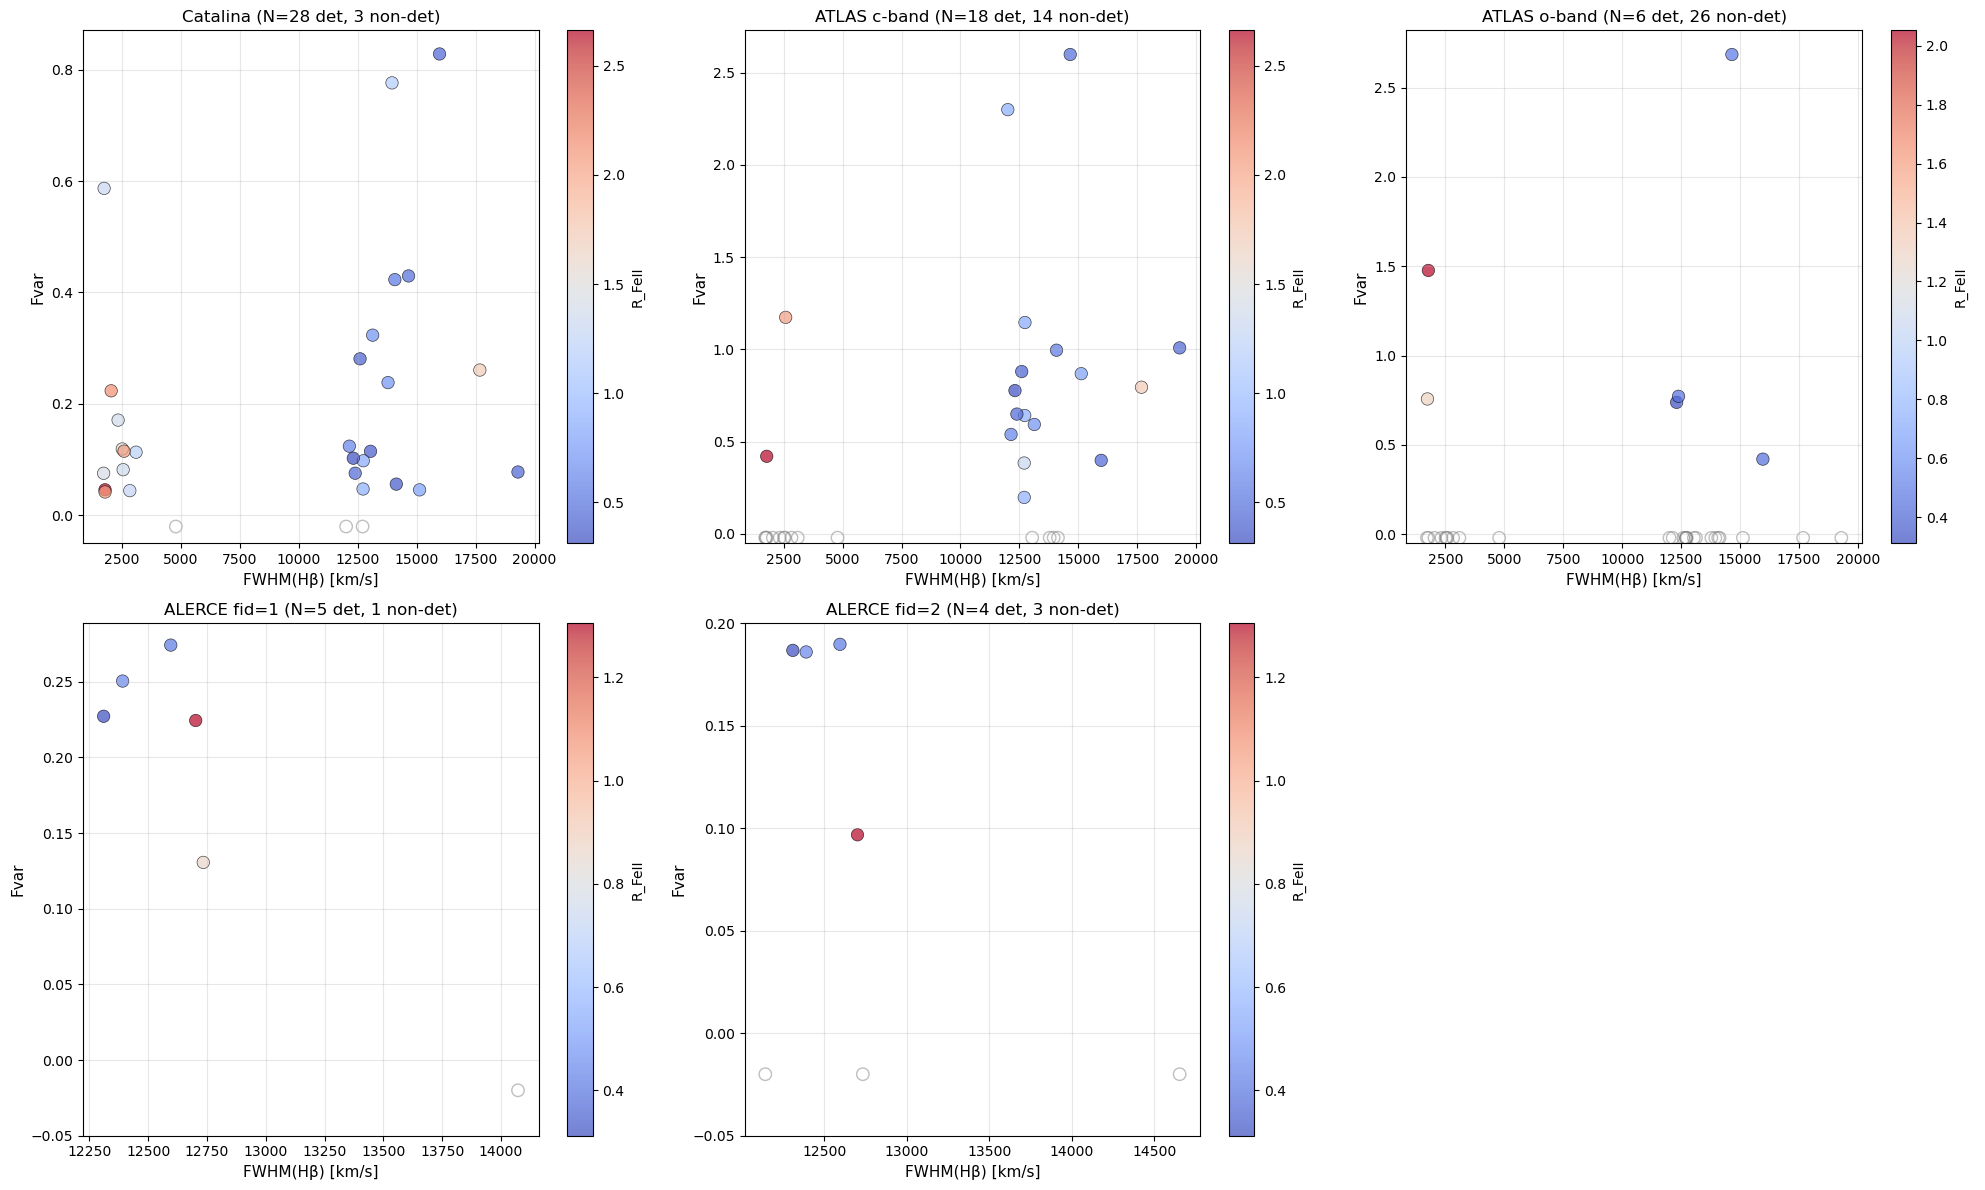

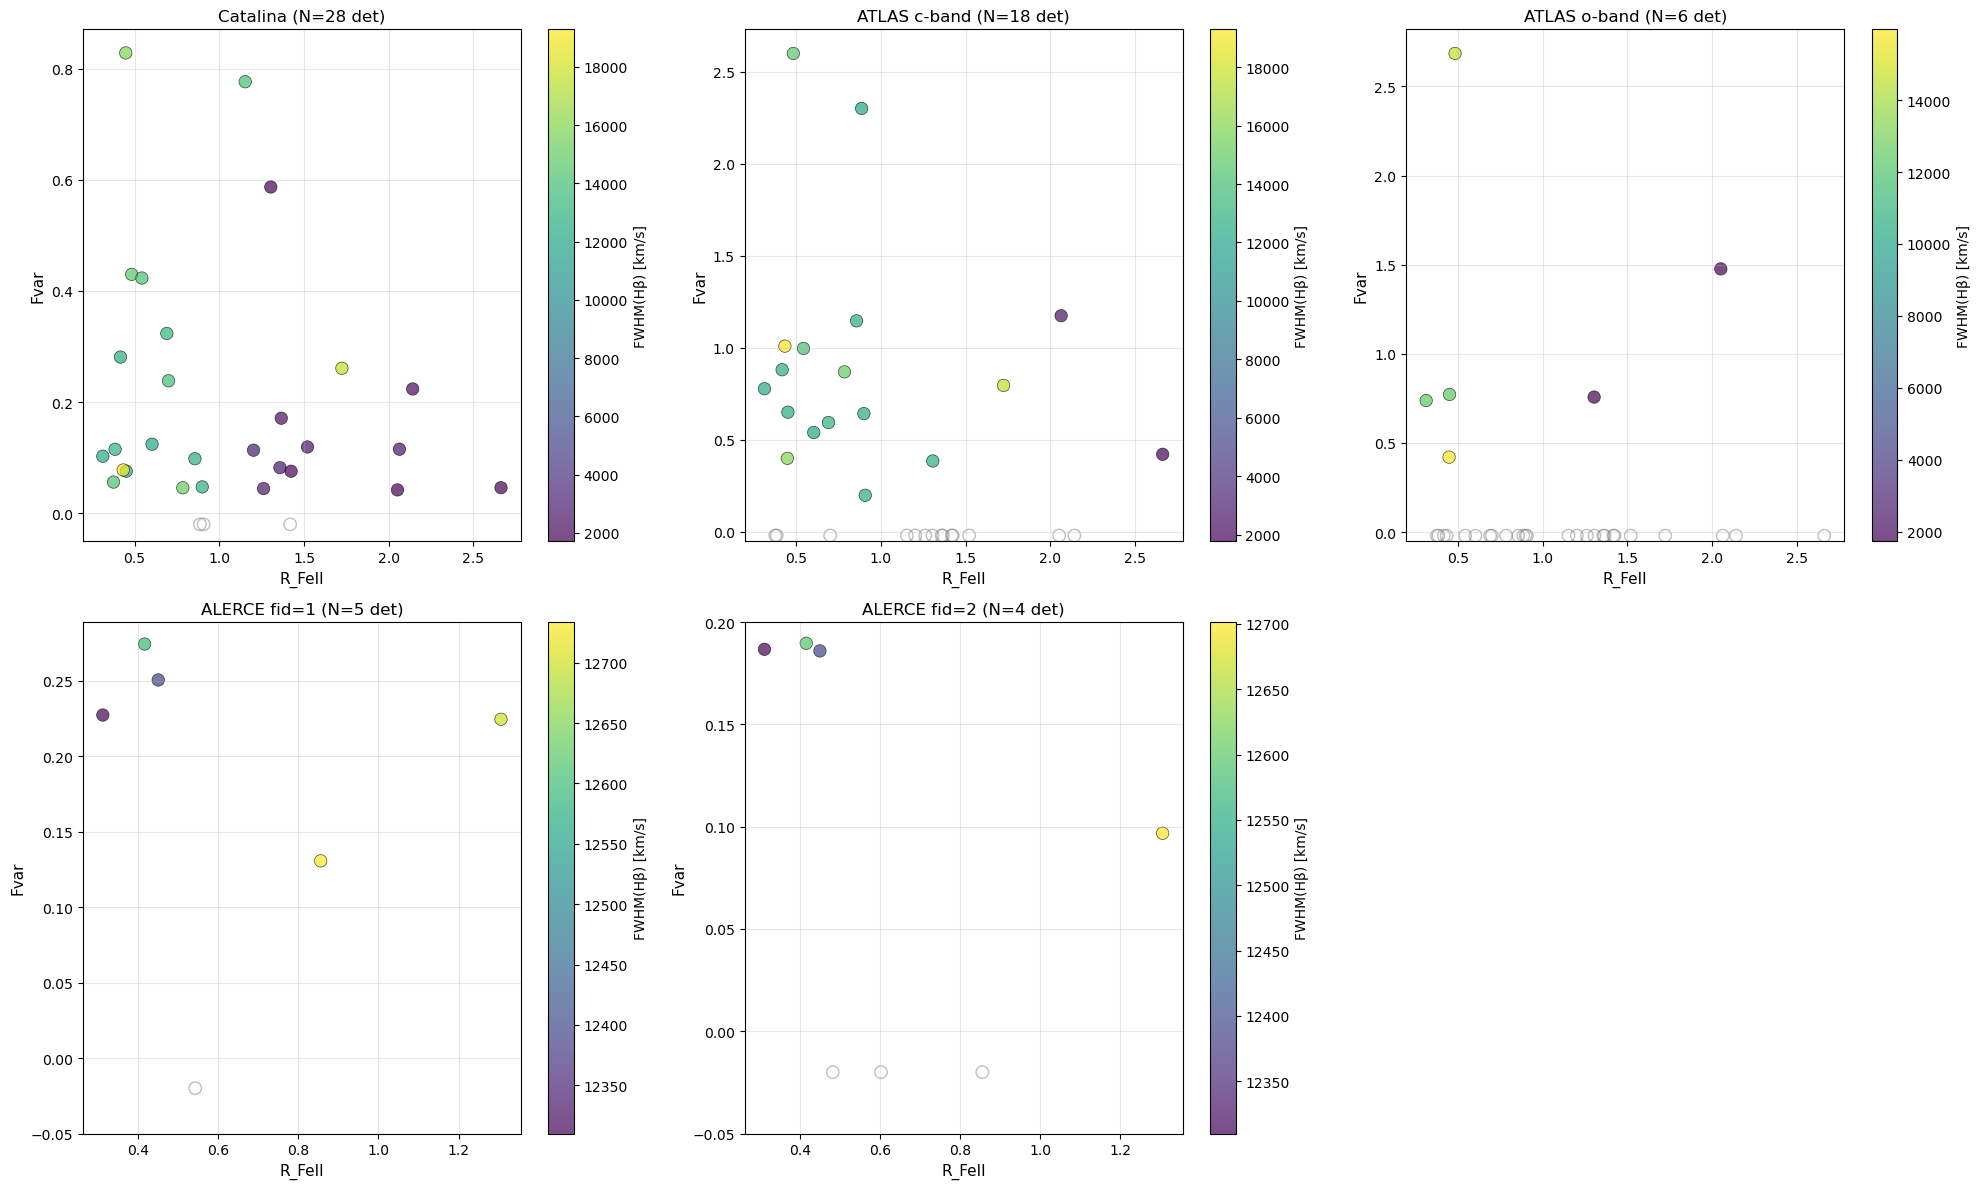

In [6]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import fitsio

# ---- Step 1: Extract R_Fe and fwhm_hbeta from FITS ----
fits_path = "/home/rohan/agn_photometry/data/dr16q_prop_May01_2024.fits"
cols_to_read = ["SDSS_NAME", "PLATE", "MJD", "FIBERID", "RA", "DEC", "FEII_OPT_EW", "HBETA_BR"]
fits_data = fitsio.read(fits_path, columns=cols_to_read)

hb_ew = fits_data["HBETA_BR"][:, 3]
hb_fwhm = fits_data["HBETA_BR"][:, 4]

df_fits = pl.DataFrame({
    "source_name": fits_data["SDSS_NAME"].astype(str),
    "PLATE": fits_data["PLATE"].astype(int),
    "MJD": fits_data["MJD"].astype(int),
    "FIBERID": fits_data["FIBERID"].astype(int),
    "RA": fits_data["RA"].astype(float),
    "DEC": fits_data["DEC"].astype(float),
    "R_Fe": (fits_data["FEII_OPT_EW"] / hb_ew).astype(float),
    "fwhm_hbeta": hb_fwhm.astype(float),
})

print(f"Extracted {df_fits.height} FITS rows with R_Fe and fwhm_hbeta")

# ---- Step 2: Load Fvar table ----
fvar_path = "/home/rohan/agn_photometry/structure_function_fractional_variability/results/fvar_all_surveys.parquet"
df_fvar = pl.read_parquet(fvar_path)
print(f"Fvar table: {df_fvar.height} rows")

# ---- Step 3: Merge Fvar + EV1 values ----
df_merged = df_fvar.join(
    df_fits.select(["source_name", "R_Fe", "fwhm_hbeta"]),
    on="source_name",
    how="left",
)

output_merged = "/home/rohan/agn_photometry/structure_function_fractional_variability/results/fvar_with_ev1.parquet"
df_merged.write_parquet(output_merged)
print(f"Merged table saved: {output_merged}")

# ---- Step 4: Create FIVE Fvar scatter plots (Catalina + ATLAS-c/o + ALERCE-1/2) ----
bands_to_plot = [
    ("Catalina", None, "Catalina"),
    ("ATLAS", "c", "ATLAS c-band"),
    ("ATLAS", "o", "ATLAS o-band"),
    ("ALERCE", "1", "ALERCE fid=1"),
    ("ALERCE", "2", "ALERCE fid=2"),
]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, (survey, band, title) in enumerate(bands_to_plot):
    ax = axes[idx]
    
    if band is None:
        subset = df_merged.filter((pl.col("survey") == survey) & (pl.col("band").is_null()))
    else:
        subset = df_merged.filter((pl.col("survey") == survey) & (pl.col("band") == band))
    
    detected = subset.filter(pl.col("Fvar").is_not_null())
    non_detected = subset.filter(pl.col("Fvar").is_null())
    
    if detected.height > 0:
        x_det = detected["fwhm_hbeta"].to_numpy()
        y_det = detected["Fvar"].to_numpy()
        c_det = detected["R_Fe"].to_numpy()
        
        scatter = ax.scatter(x_det, y_det, c=c_det, cmap="coolwarm", s=80, alpha=0.7, 
                           edgecolors="black", linewidth=0.5)
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label("R_FeII", fontsize=10)
    
    if non_detected.height > 0:
        x_nd = non_detected["fwhm_hbeta"].to_numpy()
        y_nd = np.full_like(x_nd, -0.02, dtype=float)
        ax.scatter(x_nd, y_nd, marker="o", facecolors="none", edgecolors="gray", 
                 s=80, alpha=0.5, label="Non-detected")
    
    ax.set_xlabel("FWHM(Hβ) [km/s]", fontsize=11)
    ax.set_ylabel("Fvar", fontsize=11)
    ax.set_title(f"{title} (N={detected.height} det, {non_detected.height} non-det)", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, None)

# Hide the 6th (empty) subplot
axes[5].axis("off")

plt.tight_layout()
plt.savefig("/home/rohan/agn_photometry/structure_function_fractional_variability/results/fvar_vs_fwhm.pdf", dpi=150)
print("✓ Fvar vs FWHM(Hβ) plots saved (5 panels, including Catalina)")

# ---- Step 5: Create Fvar vs R_Fe plots (same 5-panel layout) ----
fig2, axes2 = plt.subplots(2, 3, figsize=(20, 12))
axes2 = axes2.flatten()

for idx, (survey, band, title) in enumerate(bands_to_plot):
    ax = axes2[idx]
    
    if band is None:
        subset = df_merged.filter((pl.col("survey") == survey) & (pl.col("band").is_null()))
    else:
        subset = df_merged.filter((pl.col("survey") == survey) & (pl.col("band") == band))
    
    detected = subset.filter(pl.col("Fvar").is_not_null())
    non_detected = subset.filter(pl.col("Fvar").is_null())
    
    if detected.height > 0:
        x_det = detected["R_Fe"].to_numpy()
        y_det = detected["Fvar"].to_numpy()
        c_det = detected["fwhm_hbeta"].to_numpy()
        
        scatter = ax.scatter(x_det, y_det, c=c_det, cmap="viridis", s=80, alpha=0.7, 
                           edgecolors="black", linewidth=0.5)
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label("FWHM(Hβ) [km/s]", fontsize=10)
    
    if non_detected.height > 0:
        x_nd = non_detected["R_Fe"].to_numpy()
        y_nd = np.full_like(x_nd, -0.02, dtype=float)
        ax.scatter(x_nd, y_nd, marker="o", facecolors="none", edgecolors="gray", 
                 s=80, alpha=0.5, label="Non-detected")
    
    ax.set_xlabel("R_FeII", fontsize=11)
    ax.set_ylabel("Fvar", fontsize=11)
    ax.set_title(f"{title} (N={detected.height} det)", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, None)

axes2[5].axis("off")

plt.tight_layout()
plt.savefig("/home/rohan/agn_photometry/structure_function_fractional_variability/results/fvar_vs_rfe.pdf", dpi=150)
print("✓ Fvar vs R_FeII plots saved (5 panels, including Catalina)")

print("\n✓✓✓ Done. Two PDFs, 5 panels each (Catalina + ATLAS-c/o + ALERCE-1/2).")

In [7]:
import polars as pl

# Read the CSV
df = pl.read_csv("/home/rohan/agn_photometry/structure_function_fractional_variability/programs/csv_export/fvar_all_surveys.csv")

# Filter for ATLAS o-band
atlas_o = df.filter((pl.col("survey") == "ATLAS") & (pl.col("band") == "o"))

# Count nulls in Fvar column
null_count = atlas_o.filter(pl.col("Fvar").is_null()).height
total_count = atlas_o.height

print(f"ATLAS o-band: {null_count} nulls out of {total_count} rows")
print(atlas_o.select(["source_name", "band", "Fvar"]))

ATLAS o-band: 26 nulls out of 32 rows
shape: (32, 3)
┌────────────────────┬──────┬──────────┐
│ source_name        ┆ band ┆ Fvar     │
│ ---                ┆ ---  ┆ ---      │
│ str                ┆ str  ┆ f64      │
╞════════════════════╪══════╪══════════╡
│ 152942.19+350851.3 ┆ o    ┆ 0.772021 │
│ 143947.10+421317.3 ┆ o    ┆ null     │
│ 083325.69+391204.7 ┆ o    ┆ null     │
│ 090550.30+003948.1 ┆ o    ┆ null     │
│ 172052.29+590153.7 ┆ o    ┆ null     │
│ 022325.01-003612.6 ┆ o    ┆ null     │
│ 093856.54+435415.0 ┆ o    ┆ null     │
│ 143418.47+491236.5 ┆ o    ┆ null     │
│ 220546.32+005319.2 ┆ o    ┆ 1.476362 │
│ 154535.87+014958.1 ┆ o    ┆ null     │
│ 095746.83+303024.2 ┆ o    ┆ 0.738207 │
│ 092158.92+034235.7 ┆ o    ┆ null     │
│ 012715.48-001115.1 ┆ o    ┆ null     │
│ 113618.90+125554.8 ┆ o    ┆ null     │
│ 132404.20+433407.1 ┆ o    ┆ null     │
│ 133433.24-013825.3 ┆ o    ┆ null     │
│ 082311.26+435318.5 ┆ o    ┆ 2.684725 │
│ 095919.14+090659.4 ┆ o    ┆ null     │
│ 07

In [8]:
import polars as pl

df = pl.read_parquet("/home/rohan/agn_photometry/structure_function_fractional_variability/results/fvar_all_surveys.parquet")

# Group by survey and band, count nulls
summary = df.group_by(["survey", "band"]).agg([
    pl.len().alias("total"),
    pl.col("Fvar").is_null().sum().alias("nulls"),
]).with_columns(
    (pl.col("nulls") / pl.col("total") * 100).alias("null_percent")
).sort(["survey", "band"])

print(summary)

shape: (5, 5)
┌──────────┬──────┬───────┬───────┬──────────────┐
│ survey   ┆ band ┆ total ┆ nulls ┆ null_percent │
│ ---      ┆ ---  ┆ ---   ┆ ---   ┆ ---          │
│ str      ┆ str  ┆ u64   ┆ u64   ┆ f64          │
╞══════════╪══════╪═══════╪═══════╪══════════════╡
│ ALERCE   ┆ 1    ┆ 6     ┆ 1     ┆ 16.666667    │
│ ALERCE   ┆ 2    ┆ 7     ┆ 3     ┆ 42.857143    │
│ ATLAS    ┆ c    ┆ 32    ┆ 14    ┆ 43.75        │
│ ATLAS    ┆ o    ┆ 32    ┆ 26    ┆ 81.25        │
│ Catalina ┆ null ┆ 31    ┆ 3     ┆ 9.677419     │
└──────────┴──────┴───────┴───────┴──────────────┘


In [9]:
import fitsio

fits = fitsio.FITS("/home/rohan/agn_photometry/data/dr16q_prop_May01_2024.fits")
colnames = fits[1].get_colnames()
print(colnames)
fits.close()

['SDSS_NAME', 'PLATE', 'MJD', 'FIBERID', 'RA', 'DEC', 'OBJID', 'IF_BOSS_SDSS', 'Z_DR16Q', 'SOURCE_Z_DR16Q', 'Z_FIT', 'Z_SYS', 'Z_SYS_ERR', 'EBV', 'SN_MEDIAN_ALL', 'CONTI_FIT', 'CONTI_FIT_ERR', 'CONTI_STAT', 'FEII_UV', 'FEII_UV_ERR', 'FEII_UV_EW', 'FEII_UV_EW_ERR', 'FEII_OPT', 'FEII_OPT_ERR', 'FEII_OPT_EW', 'FEII_OPT_EW_ERR', 'LOGL1350', 'LOGL1350_ERR', 'LOGL1700', 'LOGL1700_ERR', 'LOGL2500', 'LOGL2500_ERR', 'LOGL3000', 'LOGL3000_ERR', 'LOGL5100', 'LOGL5100_ERR', 'HALPHA', 'HALPHA_BR', 'NII6585', 'SII6718', 'HBETA', 'HBETA_BR', 'HEII4687', 'HEII4687_BR', 'OIII5007', 'OIII5007C', 'CAII3934', 'OII3728', 'NEV3426', 'MGII', 'MGII_BR', 'CIII_ALL', 'CIII_BR', 'SIIII1892', 'ALIII1857', 'NIII1750', 'CIV', 'HEII1640', 'HEII1640_BR', 'SIIV_OIV', 'OI1304', 'LYA', 'NV1240', 'HALPHA_ERR', 'HALPHA_BR_ERR', 'NII6585_ERR', 'SII6718_ERR', 'HBETA_ERR', 'HBETA_BR_ERR', 'HEII4687_ERR', 'HEII4687_BR_ERR', 'OIII5007_ERR', 'OIII5007C_ERR', 'CAII3934_ERR', 'OII3728_ERR', 'NEV3426_ERR', 'MGII_ERR', 'MGII_BR_ERR

In [10]:
import polars as pl
import numpy as np
import fitsio
from scipy.optimize import curve_fit

catalina_path = "/home/rohan/agn_photometry/photometry/results/catalina_photometry.parquet"
alerce_path   = "/home/rohan/agn_photometry/photometry/results/alerce_photometry.parquet"
atlas_path    = "/home/rohan/agn_photometry/photometry/results/atlas_photometry.parquet"
fits_path     = "/home/rohan/agn_photometry/data/dr16q_prop_May01_2024.fits"

df_catalina = pl.read_parquet(catalina_path)
df_alerce   = pl.read_parquet(alerce_path)
df_atlas    = pl.read_parquet(atlas_path)

fits_data = fitsio.read(fits_path, columns=["SDSS_NAME", "Z_DR16Q"])
df_z = pl.DataFrame({
    "source_name": fits_data["SDSS_NAME"].astype(str),
    "z": fits_data["Z_DR16Q"].astype(float),
})

def remove_outliers_mask(vals, threshold=4.0):
    y_arr = vals.to_numpy()
    n = len(y_arr)
    if n < 3:
        return np.ones(n, dtype=bool)
    median = np.median(y_arr)
    mad = np.median(np.abs(y_arr - median))
    if mad == 0:
        return np.ones(n, dtype=bool)
    modified_z = 0.6745 * (y_arr - median) / mad
    return np.abs(modified_z) < threshold

def apply_mad_filter(df, mag_col, group_cols, err_col=None):
    kept_frames = []
    for _, sub in df.group_by(group_cols):
        mask = remove_outliers_mask(sub[mag_col])
        if err_col is not None:
            err_mask = remove_outliers_mask(sub[err_col])
            mask = mask & err_mask
        kept_frames.append(sub.filter(pl.Series(mask)))
    return pl.concat(kept_frames)

df_catalina = apply_mad_filter(df_catalina, "mag", ["source_name"], err_col="mag_err")
df_alerce   = apply_mad_filter(df_alerce, "magpsf_corr", ["source_name", "fid"], err_col="sigmapsf")
df_atlas    = apply_mad_filter(df_atlas, "m", ["source_name", "F"], err_col="dm")
df_atlas    = df_atlas.rename({"F": "band"})

df_catalina = df_catalina.with_columns([pl.lit(None, dtype=pl.Utf8).alias("band"), pl.lit("Catalina").alias("survey")])
df_alerce   = df_alerce.with_columns([pl.col("fid").cast(pl.Utf8).alias("band"), pl.lit("ALERCE").alias("survey")])
df_atlas    = df_atlas.with_columns([pl.col("band").cast(pl.Utf8), pl.lit("ATLAS").alias("survey")])

df_catalina_std = df_catalina.select([
    pl.col("survey"), pl.col("source_name"), pl.col("band"),
    pl.col("MJD").alias("mjd"), pl.col("mag"), pl.col("mag_err"),
])
df_alerce_std = df_alerce.select([
    pl.col("survey"), pl.col("source_name"), pl.col("band"),
    pl.col("mjd"), pl.col("magpsf_corr").alias("mag"), pl.col("sigmapsf").alias("mag_err"),
])
df_atlas_std = df_atlas.select([
    pl.col("survey"), pl.col("source_name"), pl.col("band"),
    pl.col("MJD").alias("mjd"), pl.col("m").alias("mag"), pl.col("dm").alias("mag_err"),
])

df_all = pl.concat([df_catalina_std, df_alerce_std, df_atlas_std], how="diagonal")
df_all = df_all.join(df_z, on="source_name", how="left", nulls_equal=True)

k = 1.4826
bin_edges = np.logspace(np.log10(14), np.log10(100), 6)  # 5 bins, rest-frame days
bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])

def power_law(dt, A50, gamma):
    return A50 * (dt / 50.0) ** gamma

def compute_sf_for_group(mjd, mag, mag_err, z):
    """Compute SF amplitude per bin (no occupancy cuts) and fit power law.
    Also returns per-bin diagnostics (dm2_median, sigma2_median) so the
    diagnostic cell doesn't need to recompute pairs from scratch."""
    n = len(mjd)
    if n < 2 or z is None or np.isnan(z):
        return None

    idx_i, idx_j = np.triu_indices(n, k=1)
    dt_obs = np.abs(mjd[idx_i] - mjd[idx_j])
    dt_rest = dt_obs / (1 + z)
    dmag = mag[idx_i] - mag[idx_j]
    sigma_pair = np.sqrt(mag_err[idx_i] ** 2 + mag_err[idx_j] ** 2)

    bin_idx = np.digitize(dt_rest, bin_edges) - 1

    A_values, valid_centers, n_pairs_per_bin = [], [], []
    bin_diagnostics = []  # (bin_center, npairs, dm2_median, sigma2_median, inner_positive)

    for b in range(len(bin_centers)):
        mask = bin_idx == b
        npairs = mask.sum()
        if npairs == 0:
            continue

        dm2_median = np.median(dmag[mask] ** 2)
        sigma2_median = np.median(sigma_pair[mask] ** 2)
        inner = k**2 * (dm2_median - sigma2_median)
        A = np.sqrt(inner) if inner > 0 else np.nan

        bin_diagnostics.append((bin_centers[b], int(npairs), dm2_median, sigma2_median, bool(inner > 0)))

        if not np.isnan(A):
            A_values.append(A)
            valid_centers.append(bin_centers[b])
            n_pairs_per_bin.append(npairs)

    result = {
        "n_bins_populated": len(A_values),
        "SF_slope": None,
        "SF_A50d": None,
        "fit_r2": None,
        "bin_diagnostics": bin_diagnostics,
    }

    if len(A_values) < 2:
        return result

    valid_centers = np.array(valid_centers)
    A_values = np.array(A_values)

    try:
        popt, _ = curve_fit(power_law, valid_centers, A_values, p0=[np.median(A_values), -0.3], maxfev=5000)
        A50_fit, gamma_fit = popt
        pred = power_law(valid_centers, *popt)
        ss_res = np.sum((A_values - pred) ** 2)
        ss_tot = np.sum((A_values - np.mean(A_values)) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else None
    except Exception:
        A50_fit, gamma_fit, r2 = None, None, None

    # Sanity filter: discard nonsensical fits (e.g. R^2 wildly negative from a degenerate fit)
    if r2 is not None and r2 < 0:
        A50_fit, gamma_fit = None, None

    result["SF_slope"] = gamma_fit
    result["SF_A50d"] = A50_fit
    result["fit_r2"] = r2
    return result

results = []
for (survey, source_name, band), sub in df_all.group_by(["survey", "source_name", "band"]):
    mjd = sub["mjd"].to_numpy()
    mag = sub["mag"].to_numpy()
    mag_err = sub["mag_err"].to_numpy()
    z_vals = sub["z"].drop_nulls()
    z = z_vals[0] if len(z_vals) > 0 else None

    sf_result = compute_sf_for_group(mjd, mag, mag_err, z)
    if sf_result is None:
        continue

    results.append({
        "survey": survey,
        "source_name": source_name,
        "band": band,
        "N": len(mjd),
        "z": z,
        "n_bins_populated": sf_result["n_bins_populated"],
        "SF_slope": sf_result["SF_slope"],
        "SF_A50d": sf_result["SF_A50d"],
        "fit_r2": sf_result["fit_r2"],
    })


sf_raw_results = results  # NOTE: this still only has the summary fields above;


df_sf = pl.DataFrame([{k: v for k, v in r.items()} for r in results])

pl.Config.set_tbl_rows(-1)
print("=== Structure Function Results ===")
print(df_sf.select(["survey", "source_name", "band", "N", "z", "n_bins_populated", "SF_slope", "SF_A50d", "fit_r2"]).sort(["survey", "source_name"]))

output_path = "/home/rohan/agn_photometry/structure_function_fractional_variability/results/sf_all_surveys.parquet"
df_sf.write_parquet(output_path)
print(f"\nSaved to {output_path}")




/tmp/ipykernel_4512/604878864.py:127: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(power_law, valid_centers, A_values, p0=[np.median(A_values), -0.3], maxfev=5000)


=== Structure Function Results ===
shape: (118, 9)
┌──────────┬───────────────┬──────┬──────┬───┬───────────────┬───────────┬──────────┬──────────────┐
│ survey   ┆ source_name   ┆ band ┆ N    ┆ … ┆ n_bins_popula ┆ SF_slope  ┆ SF_A50d  ┆ fit_r2       │
│ ---      ┆ ---           ┆ ---  ┆ ---  ┆   ┆ ted           ┆ ---       ┆ ---      ┆ ---          │
│ str      ┆ str           ┆ str  ┆ i64  ┆   ┆ ---           ┆ f64       ┆ f64      ┆ f64          │
│          ┆               ┆      ┆      ┆   ┆ i64           ┆           ┆          ┆              │
╞══════════╪═══════════════╪══════╪══════╪═══╪═══════════════╪═══════════╪══════════╪══════════════╡
│ ALERCE   ┆ 001255.59+014 ┆ 2    ┆ 103  ┆ … ┆ 0             ┆ null      ┆ null     ┆ null         │
│          ┆ 750.9         ┆      ┆      ┆   ┆               ┆           ┆          ┆              │
│ ALERCE   ┆ 001255.59+014 ┆ 1    ┆ 195  ┆ … ┆ 1             ┆ null      ┆ null     ┆ null         │
│          ┆ 750.9         ┆      ┆     

In [11]:
null_summary = df_sf.group_by(["survey", "band"]).agg([
    pl.len().alias("total"),
    pl.col("SF_slope").is_null().sum().alias("null_slope"),
]).with_columns(
    (pl.col("null_slope") / pl.col("total") * 100).alias("null_percent")
).sort(["survey", "band"])

print("=== SF null-slope rate by survey/band ===")
print(null_summary)

# ---- B) Fits with suspiciously poor R^2 (kept but worth flagging in presentation) ----
poor_fits = df_sf.filter(
    (pl.col("fit_r2").is_not_null()) & (pl.col("fit_r2") < 0.3)
)
print(f"\n=== Fits with R^2 < 0.3 ({poor_fits.height} rows) ===")
print(poor_fits.select(["survey", "source_name", "band", "n_bins_populated", "SF_slope", "fit_r2"]))

# ---- C) For a specific zero-bin source: recompute per-bin dm2/sigma2 to confirm noise floor ----
# Only recomputes for sources you actually want to inspect — cheap since it's per-source, not all 118.
def inspect_source_bins(survey, source_name, band, df_all=df_all):
    sub = df_all.filter(
        (pl.col("survey") == survey) &
        (pl.col("source_name") == source_name) &
        (pl.col("band") == band if band is not None else pl.col("band").is_null())
    )
    mjd = sub["mjd"].to_numpy()
    mag = sub["mag"].to_numpy()
    mag_err = sub["mag_err"].to_numpy()
    z = sub["z"].drop_nulls()[0]

    idx_i, idx_j = np.triu_indices(len(mjd), k=1)
    dt_rest = np.abs(mjd[idx_i] - mjd[idx_j]) / (1 + z)
    dmag = mag[idx_i] - mag[idx_j]
    sigma_pair = np.sqrt(mag_err[idx_i]**2 + mag_err[idx_j]**2)
    bin_idx = np.digitize(dt_rest, bin_edges) - 1

    print(f"\n--- {survey} / {source_name} / band={band} ---")
    for b in range(len(bin_centers)):
        mask = bin_idx == b
        npairs = mask.sum()
        if npairs == 0:
            print(f"  bin {b} ({bin_centers[b]:.1f}d): 0 pairs")
            continue
        dm2 = np.median(dmag[mask] ** 2)
        sig2 = np.median(sigma_pair[mask] ** 2)
        print(f"  bin {b} ({bin_centers[b]:.1f}d): npairs={npairs}, dm2_median={dm2:.4f}, sigma2_median={sig2:.4f}, signal>noise={dm2 > sig2}")

# Example usage — change source/band to inspect any zero-bin case:
inspect_source_bins("ATLAS", "001255.59+014750.9", "o")

=== SF null-slope rate by survey/band ===
shape: (6, 5)
┌──────────┬──────┬───────┬────────────┬──────────────┐
│ survey   ┆ band ┆ total ┆ null_slope ┆ null_percent │
│ ---      ┆ ---  ┆ ---   ┆ ---        ┆ ---          │
│ str      ┆ str  ┆ u64   ┆ u64        ┆ f64          │
╞══════════╪══════╪═══════╪════════════╪══════════════╡
│ ALERCE   ┆ 1    ┆ 10    ┆ 7          ┆ 70.0         │
│ ALERCE   ┆ 2    ┆ 12    ┆ 10         ┆ 83.333333    │
│ ALERCE   ┆ 3    ┆ 1     ┆ 1          ┆ 100.0        │
│ ATLAS    ┆ c    ┆ 32    ┆ 28         ┆ 87.5         │
│ ATLAS    ┆ o    ┆ 32    ┆ 28         ┆ 87.5         │
│ Catalina ┆ null ┆ 31    ┆ 23         ┆ 74.193548    │
└──────────┴──────┴───────┴────────────┴──────────────┘

=== Fits with R^2 < 0.3 (9 rows) ===
shape: (9, 6)
┌──────────┬────────────────────┬──────┬──────────────────┬───────────┬──────────────┐
│ survey   ┆ source_name        ┆ band ┆ n_bins_populated ┆ SF_slope  ┆ fit_r2       │
│ ---      ┆ ---                ┆ ---  ┆ ---  

In [12]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import fitsio

# ---- Load SF results + EV1 values ----
sf_path = "/home/rohan/agn_photometry/structure_function_fractional_variability/results/sf_all_surveys.parquet"
fits_path = "/home/rohan/agn_photometry/data/dr16q_prop_May01_2024.fits"

df_sf = pl.read_parquet(sf_path)

fits_data = fitsio.read(fits_path, columns=["SDSS_NAME", "FEII_OPT_EW", "HBETA_BR"])
hb_ew = fits_data["HBETA_BR"][:, 3]
hb_fwhm = fits_data["HBETA_BR"][:, 4]
df_fits = pl.DataFrame({
    "source_name": fits_data["SDSS_NAME"].astype(str),
    "R_Fe": (fits_data["FEII_OPT_EW"] / hb_ew).astype(float),
    "fwhm_hbeta": hb_fwhm.astype(float),
})

df_sf_ev1 = df_sf.join(df_fits, on="source_name", how="left")

bands_to_plot = [
    ("Catalina", None, "Catalina"),
    ("ATLAS", "c", "ATLAS c-band"),
    ("ATLAS", "o", "ATLAS o-band"),
    ("ALERCE", "1", "ALERCE fid=1"),
    ("ALERCE", "2", "ALERCE fid=2"),
]

def make_sf_plot_page(ax_grid, x_col, x_label, cmap, cbar_label, r2_cutoff=None):
    for idx, (survey, band, title) in enumerate(bands_to_plot):
        ax = ax_grid[idx]

        if band is None:
            subset = df_sf_ev1.filter((pl.col("survey") == survey) & (pl.col("band").is_null()))
        else:
            subset = df_sf_ev1.filter((pl.col("survey") == survey) & (pl.col("band") == band))

        if r2_cutoff is not None:
            subset = subset.filter((pl.col("fit_r2").is_not_null()) & (pl.col("fit_r2") >= r2_cutoff))

        detected = subset.filter(pl.col("SF_slope").is_not_null())
        non_detected = subset.filter(pl.col("SF_slope").is_null())

        if detected.height > 0:
            x = detected[x_col].to_numpy()
            y = detected["SF_slope"].to_numpy()
            c = detected["fit_r2"].to_numpy()
            scatter = ax.scatter(x, y, c=c, cmap=cmap, s=80, alpha=0.8,
                                  edgecolors="black", linewidth=0.5, vmin=0, vmax=1)
            cbar = plt.colorbar(scatter, ax=ax)
            cbar.set_label(cbar_label, fontsize=10)

        if r2_cutoff is None and non_detected.height > 0:
            xn = non_detected[x_col].to_numpy()
            yn = np.zeros_like(xn)
            ax.scatter(xn, yn, marker="o", facecolors="none", edgecolors="gray",
                       s=60, alpha=0.4, label="No fit")

        ax.set_xlabel(x_label, fontsize=11)
        ax.set_ylabel("SF slope (γ)", fontsize=11)
        n_shown = detected.height
        n_total = subset.height
        ax.set_title(f"{title} (N={n_shown}/{n_total} fit)", fontsize=12)
        ax.grid(True, alpha=0.3)

    if len(ax_grid) > len(bands_to_plot):
        ax_grid[-1].axis("off")

# ============================================================
# Version 1: ALL available SF values
# ============================================================
output_all = "/home/rohan/agn_photometry/structure_function_fractional_variability/results/sf_vs_ev1_all.pdf"
with PdfPages(output_all) as pdf:
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    make_sf_plot_page(axes.flatten(), "fwhm_hbeta", "FWHM(Hβ) [km/s]", "coolwarm", "fit R²")
    plt.suptitle("SF slope vs FWHM(Hβ) — all available fits", fontsize=14)
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    make_sf_plot_page(axes.flatten(), "R_Fe", "R_FeII", "viridis", "fit R²")
    plt.suptitle("SF slope vs R_FeII — all available fits", fontsize=14)
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

print(f"✓ Saved: {output_all}")

# ============================================================
# Version 2: only R^2 >= 0.3 (good fits)
# ============================================================
output_good = "/home/rohan/agn_photometry/structure_function_fractional_variability/results/sf_vs_ev1_good_fits.pdf"
with PdfPages(output_good) as pdf:
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    make_sf_plot_page(axes.flatten(), "fwhm_hbeta", "FWHM(Hβ) [km/s]", "coolwarm", "fit R²", r2_cutoff=0.3)
    plt.suptitle("SF slope vs FWHM(Hβ) — R² ≥ 0.3 only", fontsize=14)
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    make_sf_plot_page(axes.flatten(), "R_Fe", "R_FeII", "viridis", "fit R²", r2_cutoff=0.3)
    plt.suptitle("SF slope vs R_FeII — R² ≥ 0.3 only", fontsize=14)
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

print(f"✓ Saved: {output_good}")

/tmp/ipykernel_4512/750567256.py:18: RuntimeWarning: divide by zero encountered in divide
  "R_Fe": (fits_data["FEII_OPT_EW"] / hb_ew).astype(float),
/tmp/ipykernel_4512/750567256.py:18: RuntimeWarning: invalid value encountered in divide
  "R_Fe": (fits_data["FEII_OPT_EW"] / hb_ew).astype(float),


✓ Saved: /home/rohan/agn_photometry/structure_function_fractional_variability/results/sf_vs_ev1_all.pdf
✓ Saved: /home/rohan/agn_photometry/structure_function_fractional_variability/results/sf_vs_ev1_good_fits.pdf
